# PHẦN 1: KHẢO SÁT VÀ LÀM SẠCH DỮ LIỆU (DATA PREPROCESSING)
Mục tiêu: Đọc dữ liệu thô, đánh giá tổng quan về cấu trúc, kiểu dữ liệu và làm sạch các dữ liệu lỗi trước khi đưa vào phân tích chuyên sâu.

In [22]:
import pandas as pd

print("="*70)
print(f"{'TỔNG QUAN DỮ LIỆU GỐC (RAW DATA) - SUPERSTORE':^70}")
print("="*70)

# 1. Đọc file 
df_raw = None
for enc in ['utf-8', 'windows-1252', 'latin1']:
    try: 
        df_raw = pd.read_csv('Superstore.csv', encoding=enc)
        break
    except: 
        continue

if df_raw is not None:
    if 'Order Date' in df_raw.columns:
        date_col = 'Order Date'
    elif 'Date' in df_raw.columns:
        date_col = 'Date'
    else:
        date_col = None
        
    if date_col:
        temp_date = pd.to_datetime(df_raw[date_col], dayfirst=True, errors='coerce')
        min_date = temp_date.min()
        max_date = temp_date.max()
        time_range = f"Từ {min_date.strftime('%d/%m/%Y')} đến {max_date.strftime('%d/%m/%Y')}"
        total_days = (max_date - min_date).days
    else:
        time_range = "Không tìm thấy cột thời gian."
        total_days = 0

    total_rows = df_raw.shape[0]
    total_cols = df_raw.shape[1]
    features = df_raw.columns.tolist()
    
    print(f"1. Kích thước dữ liệu : {total_rows:,.0f} hàng (rows) x {total_cols} cột (columns/features)")
    print(f"2. Giai đoạn lịch sử   : {time_range} (Khoảng {total_days/365:.1f} năm)\n")
    
    print("3. Bảng phân tích chi tiết từng đặc trưng (Cột):")
    print("-" * 70)
    print(f"{'STT':<4} | {'Tên đặc trưng (Column)':<25} | {'Kiểu dữ liệu':<15} | {'Giá trị Rỗng (NaN)':<15}")
    print("-" * 70)
    
    for i, col in enumerate(features, 1):
        dtype = str(df_raw[col].dtype)
        if dtype == 'object': dtype = 'Chữ / Text'
        elif 'float' in dtype: dtype = 'Số thực (Float)'
        elif 'int' in dtype: dtype = 'Số nguyên (Int)'
            
        nan_count = df_raw[col].isnull().sum()
        nan_percent = (nan_count / total_rows) * 100
        nan_str = f"{nan_count} ({nan_percent:.1f}%)" if nan_count > 0 else "0"
        
        print(f"{i:<4} | {col:<25} | {dtype:<15} | {nan_str:<15}")
    print("-" * 70)
else:
    print("Không thể đọc được file 'Superstore.csv'.")

            TỔNG QUAN DỮ LIỆU GỐC (RAW DATA) - SUPERSTORE             
1. Kích thước dữ liệu : 9,994 hàng (rows) x 21 cột (columns/features)
2. Giai đoạn lịch sử   : Từ 04/01/2011 đến 31/12/2014 (Khoảng 4.0 năm)

3. Bảng phân tích chi tiết từng đặc trưng (Cột):
----------------------------------------------------------------------
STT  | Tên đặc trưng (Column)    | Kiểu dữ liệu    | Giá trị Rỗng (NaN)
----------------------------------------------------------------------
1    | Row ID                    | Số nguyên (Int) | 0              
2    | Order ID                  | str             | 0              
3    | Order Date                | str             | 0              
4    | Ship Date                 | str             | 0              
5    | Ship Mode                 | str             | 0              
6    | Customer ID               | str             | 0              
7    | Customer Name             | str             | 0              
8    | Segment                   | str   

## 1.1. Tiền xử lý và làm sạch dữ liệu
Thực hiện chuyển đổi kiểu dữ liệu thời gian, loại bỏ các giá trị rỗng và các đơn hàng không hợp lệ (hàng hoàn trả, số lượng <= 0).

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("=== BƯỚC 1: NẠP VÀ LÀM SẠCH DỮ LIỆU THÔ ===")

# 1. Định dạng trục thời gian
df_raw['Date'] = pd.to_datetime(df_raw['Order Date'], dayfirst=True, errors='coerce').dt.normalize()

# 2. Làm sạch các dữ liệu lỗi
missing_before = len(df_raw)
df_raw = df_raw.dropna(subset=['Date', 'Category', 'Quantity', 'Sales'])
df_raw = df_raw[(df_raw['Quantity'] > 0) & (df_raw['Sales'] > 0)] 
print(f"-> Đã lọc bỏ {missing_before - len(df_raw)} dòng rác/lỗi/hoàn trả.")
print(f"-> Kích thước dữ liệu sạch: {df_raw.shape}")

=== BƯỚC 1: NẠP VÀ LÀM SẠCH DỮ LIỆU THÔ ===
-> Đã lọc bỏ 0 dòng rác/lỗi/hoàn trả.
-> Kích thước dữ liệu sạch: (9994, 22)


# PHẦN 2: KHẢO SÁT TOÀN DIỆN BIẾN (COMPREHENSIVE RAW EDA)

Tập dữ liệu gốc bao gồm 21 biến số. Việc đánh giá độc lập và chéo các biến này giúp định hình chiến lược Feature Engineering:
- Nhóm biến Số học (Numeric): Đánh giá phân phối, ngoại lai (Outliers) và tương quan tuyến tính.
- Nhóm biến Phân loại (Categorical): Đánh giá tỷ trọng đóng góp của từng nhóm (Ngành hàng, Khu vực, Phân khúc).
- Nhóm biến Thời gian (Temporal): Nhận diện xu hướng (Trend) và tính mùa vụ (Seasonality).
- Nhóm biến Định danh (IDs): Đánh giá tính đa dạng của tệp khách hàng và sản phẩm.

        ĐÁNH GIÁ TƯƠNG QUAN VÀ CHẤT LƯỢNG ĐẶC TRƯNG CHUẨN HỌC MÁY (STATISTICAL ML EDA)         


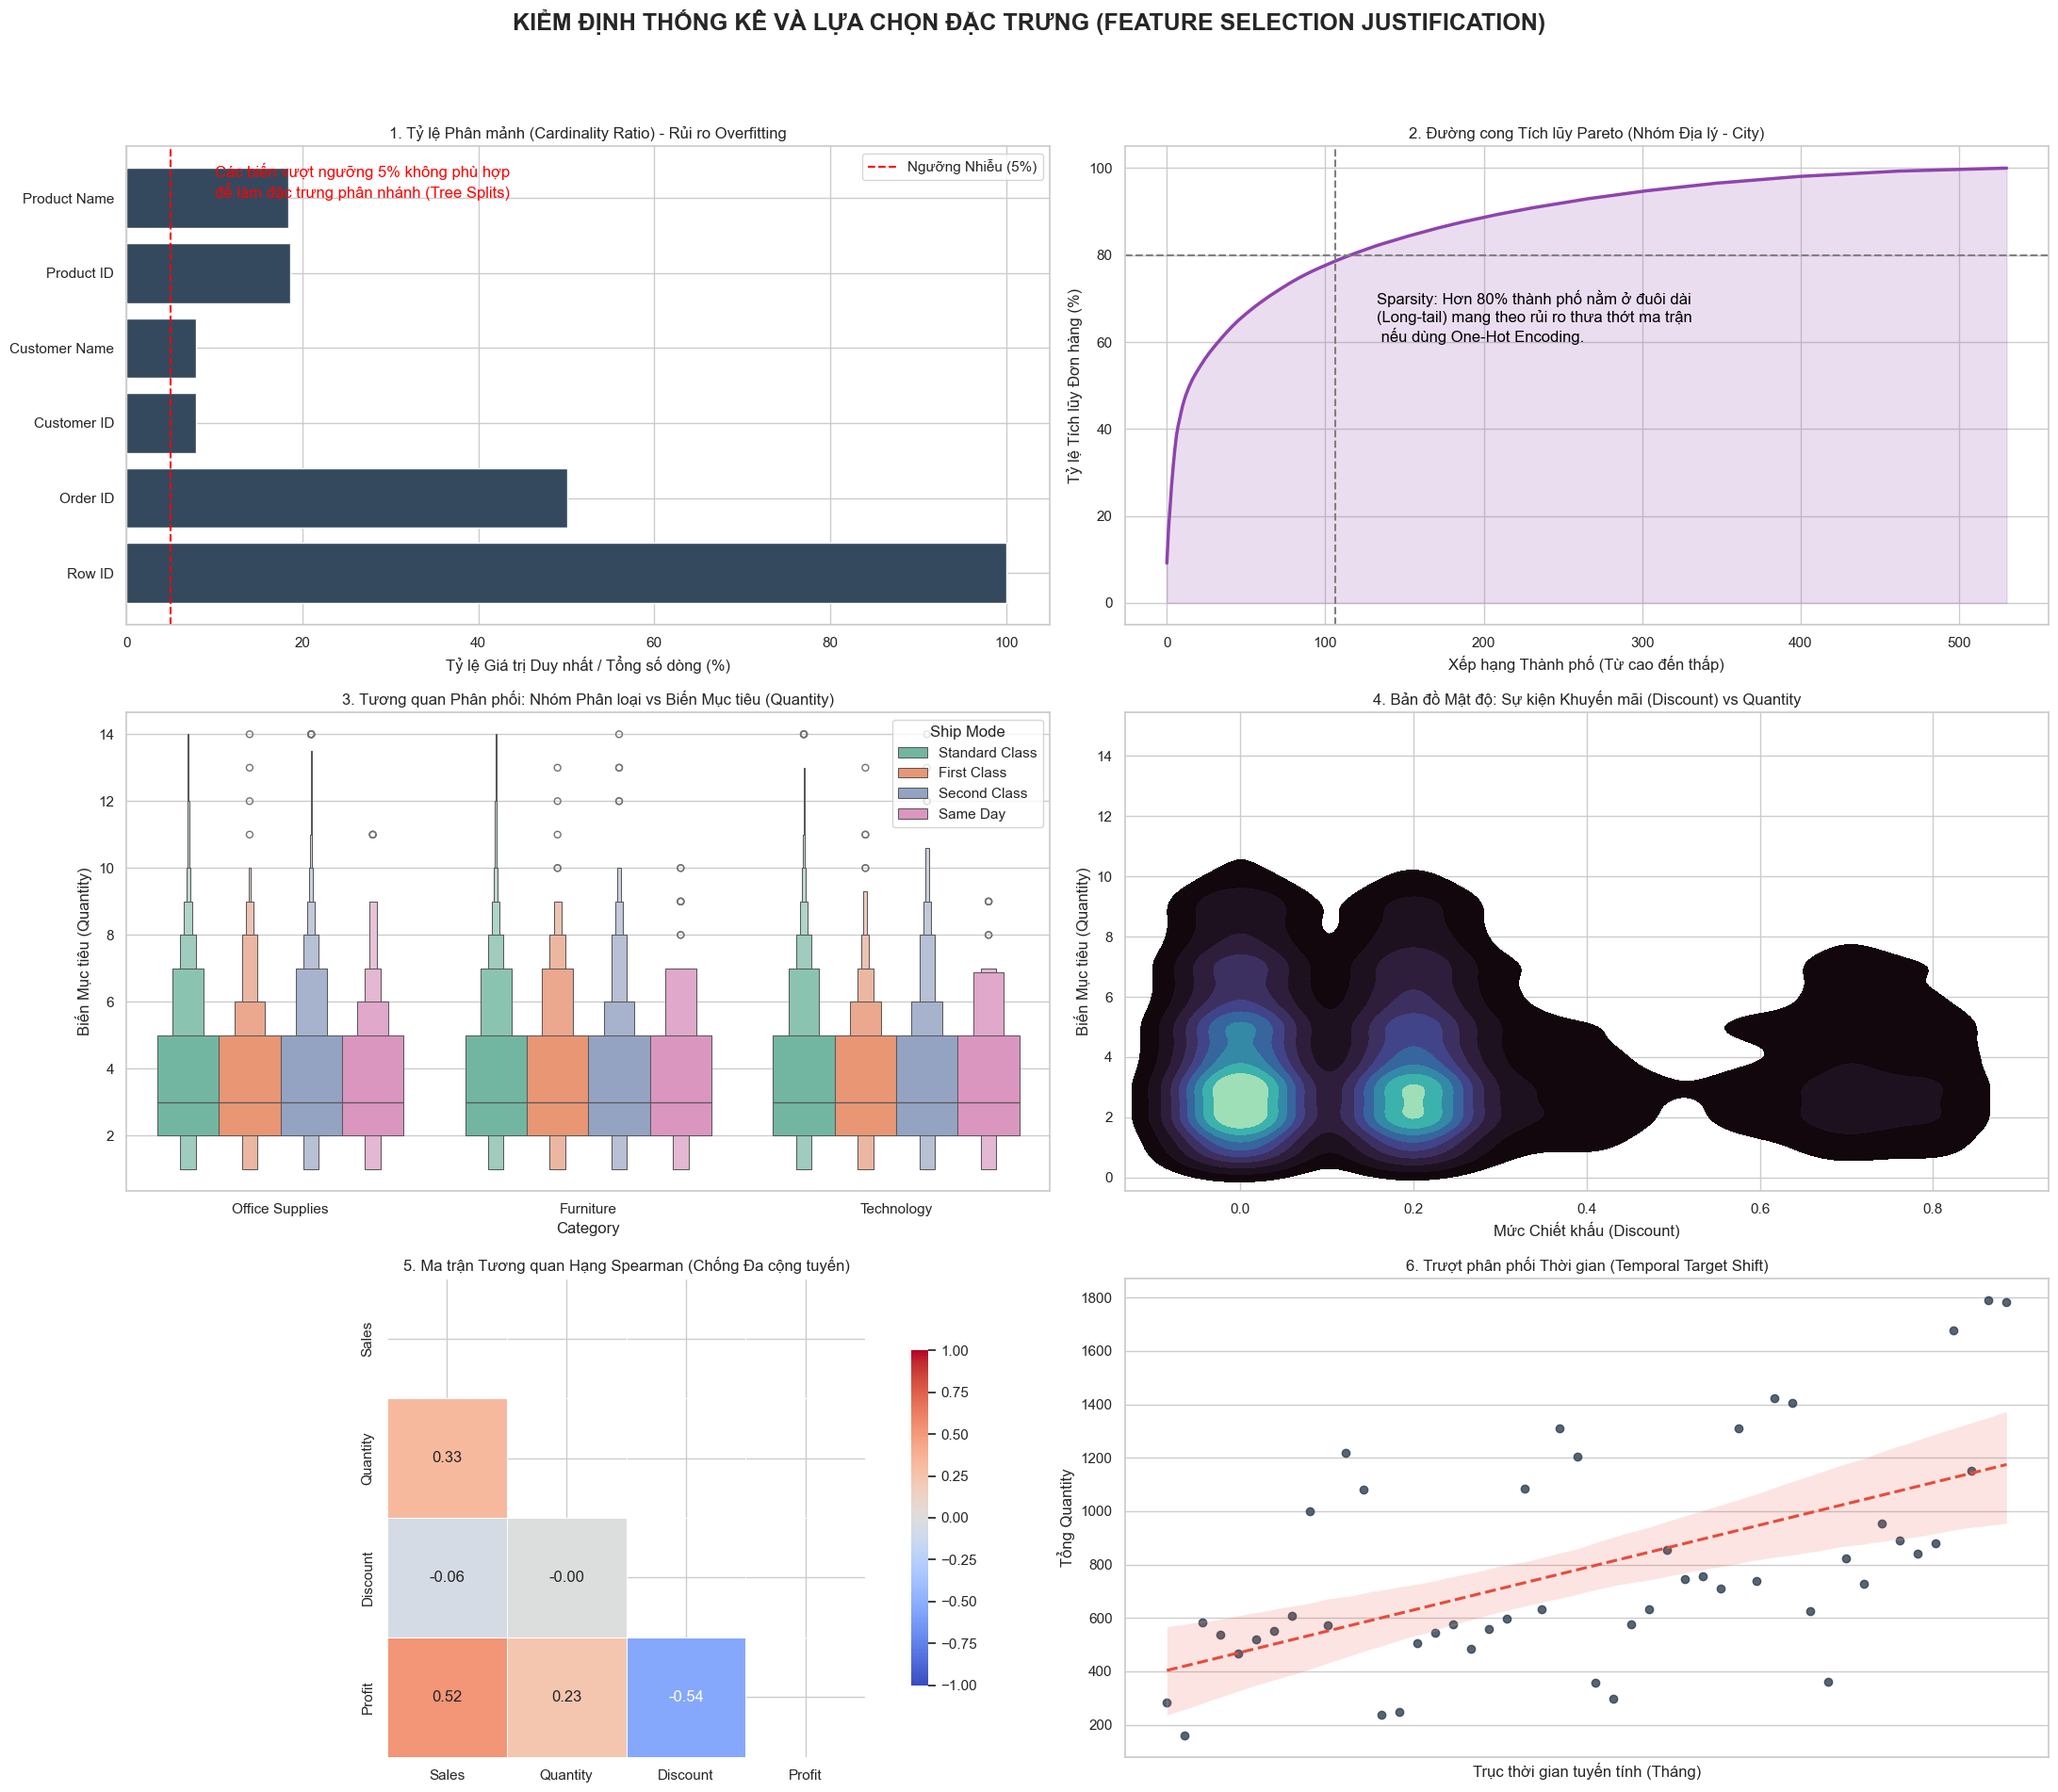


 KẾT LUẬN KIỂM ĐỊNH CHO MÔ HÌNH HỌC MÁY (VERDICT):
- Biểu đồ 1 (Cardinality): Các biến ID có tỷ lệ phân mảnh gần 100% (tương đương mỗi dòng 1 ID). Về mặt toán học, chúng tạo ra ma trận nhiễu. Lệnh DROP là bắt buộc.
- Biểu đồ 2 (Sparsity): 80% dữ liệu tập trung ở 20% Thành phố (Quy luật Pareto). Nếu dùng One-Hot Encoding cho City/State, không gian vector sẽ bị thưa thớt (Sparse Matrix) dẫn đến lời giải cực tiểu cục bộ. Bỏ qua nhóm biến này.
- Biểu đồ 3 (Boxen Distribution): Phân phối của biến Target gần như đồng dạng giữa các Ship Mode và Category. Điều này chứng tỏ tác động tuyến tính của chúng là thấp, cần kết hợp thêm các biến phi tuyến khác.
- Biểu đồ 4 (Density): Vùng mật độ cao nhất tập trung ở Discount = 0 và 0.2. Dữ liệu bị rỗng ở các mức chiết khấu khác. Đưa trực tiếp Discount vào mô hình sẽ gây sai số phân phối.
- Biểu đồ 5 (Collinearity): Spearman Correlation cho thấy sự phụ thuộc lẫn nhau phức tạp. Cần gộp Sales, Quantity và Discount thành 'Effective_Price' để giảm bậc tự d

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("="*95)
print(f"{'ĐÁNH GIÁ TƯƠNG QUAN VÀ CHẤT LƯỢNG ĐẶC TRƯNG CHUẨN HỌC MÁY (STATISTICAL ML EDA)':^95}")
print("="*95)

fig, axes = plt.subplots(3, 2, figsize=(22, 20))
fig.suptitle('KIỂM ĐỊNH THỐNG KÊ VÀ LỰA CHỌN ĐẶC TRƯNG (FEATURE SELECTION JUSTIFICATION)', fontsize=18, fontweight='bold')

# Đảm bảo có cột Quantity làm Target tạm thời để khảo sát
target_col = 'Quantity'

# =====================================================================
# 1. KIỂM ĐỊNH NHIỄU (NOISE): CARDINALITY CỦA NHÓM ID & NAME
# =====================================================================
id_cols = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name']
cardinality_ratio = [df_raw[col].nunique() / len(df_raw) * 100 for col in id_cols]

axes[0,0].barh(id_cols, cardinality_ratio, color='#34495e')
axes[0,0].axvline(5, color='red', linestyle='--', label='Ngưỡng Nhiễu (5%)')
axes[0,0].set_title('1. Tỷ lệ Phân mảnh (Cardinality Ratio) - Rủi ro Overfitting')
axes[0,0].set_xlabel('Tỷ lệ Giá trị Duy nhất / Tổng số dòng (%)')
axes[0,0].text(10, 5, 'Các biến vượt ngưỡng 5% không phù hợp\nđể làm đặc trưng phân nhánh (Tree Splits)', color='red')
axes[0,0].legend()

# =====================================================================
# 2. KIỂM ĐỊNH ĐỘ THƯA THỚT (SPARSITY): NHÓM ĐỊA LÝ (CITY/STATE)
# =====================================================================
# Sử dụng đường cong Pareto để chứng minh dữ liệu bị đuôi dài (Long-tail)
city_counts = df_raw['City'].value_counts(normalize=True).cumsum() * 100
city_counts_values = city_counts.values

axes[0,1].plot(np.arange(len(city_counts_values)), city_counts_values, color='#8e44ad', linewidth=2.5)
axes[0,1].axhline(80, color='gray', linestyle='--')
axes[0,1].axvline(len(city_counts_values)*0.2, color='gray', linestyle='--')
axes[0,1].set_title('2. Đường cong Tích lũy Pareto (Nhóm Địa lý - City)')
axes[0,1].set_xlabel('Xếp hạng Thành phố (Từ cao đến thấp)')
axes[0,1].set_ylabel('Tỷ lệ Tích lũy Đơn hàng (%)')
axes[0,1].fill_between(np.arange(len(city_counts_values)), city_counts_values, color='#9b59b6', alpha=0.2)
axes[0,1].text(len(city_counts_values)*0.25, 60, 'Sparsity: Hơn 80% thành phố nằm ở đuôi dài\n(Long-tail) mang theo rủi ro thưa thớt ma trận\n nếu dùng One-Hot Encoding.', color='black')

# =====================================================================
# 3. KIỂM ĐỊNH TÍN HIỆU (SIGNAL): NHÓM PHÂN LOẠI VS TARGET (BOXEN PLOT)
# =====================================================================
# Sử dụng Boxenplot (Letter-value plot) chuẩn học thuật để xem sự dịch chuyển phân phối
sns.boxenplot(data=df_raw, x='Category', y=target_col, hue='Ship Mode', palette='Set2', ax=axes[1,0])
axes[1,0].set_title(f'3. Tương quan Phân phối: Nhóm Phân loại vs Biến Mục tiêu ({target_col})')
axes[1,0].set_ylabel(f'Biến Mục tiêu ({target_col})')
axes[1,0].legend(title='Ship Mode', loc='upper right')

# =====================================================================
# 4. KIỂM ĐỊNH PHI TUYẾN: MẬT ĐỘ TÁC ĐỘNG CỦA DISCOUNT LÊN TARGET
# =====================================================================
# Sử dụng KDE Plot (Kernel Density Estimation) hai chiều
sns.kdeplot(data=df_raw, x='Discount', y=target_col, fill=True, cmap='mako', thresh=0.05, ax=axes[1,1])
axes[1,1].set_title(f'4. Bản đồ Mật độ: Sự kiện Khuyến mãi (Discount) vs {target_col}')
axes[1,1].set_xlabel('Mức Chiết khấu (Discount)')
axes[1,1].set_ylabel(f'Biến Mục tiêu ({target_col})')

# =====================================================================
# 5. ĐA CỘNG TUYẾN (MULTICOLLINEARITY): NHÓM SỐ HỌC
# =====================================================================
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df_raw[numeric_cols].corr(method='spearman') # Dùng Spearman tốt hơn Pearson cho dữ liệu lệch
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Che nửa trên của ma trận

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .7}, ax=axes[2,0])
axes[2,0].set_title('5. Ma trận Tương quan Hạng Spearman (Chống Đa cộng tuyến)')

# =====================================================================
# 6. TRƯỢT PHỐI CẢNH THỜI GIAN (TEMPORAL SHIFT): XU HƯỚNG MỤC TIÊU
# =====================================================================
df_raw['YearMonth'] = df_raw['Date'].dt.to_period('M')
monthly_target = df_raw.groupby('YearMonth')[target_col].sum().reset_index()
monthly_target['YearMonth_Str'] = monthly_target['YearMonth'].astype(str)

sns.regplot(data=monthly_target.reset_index(), x='index', y=target_col, 
            scatter_kws={'color':'#2c3e50'}, line_kws={'color':'#e74c3c', 'linestyle':'--'}, ax=axes[2,1])
axes[2,1].set_title(f'6. Trượt phân phối Thời gian (Temporal Target Shift)')
axes[2,1].set_xlabel('Trục thời gian tuyến tính (Tháng)')
axes[2,1].set_ylabel(f'Tổng {target_col}')
axes[2,1].set_xticks([]) # Ẩn nhãn trục X để đồ thị sạch hơn

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- BÁO CÁO LUẬN ĐIỂM CHUẨN HỌC THUẬT ---
print("\n KẾT LUẬN KIỂM ĐỊNH CHO MÔ HÌNH HỌC MÁY (VERDICT):")
print("- Biểu đồ 1 (Cardinality): Các biến ID có tỷ lệ phân mảnh gần 100% (tương đương mỗi dòng 1 ID). Về mặt toán học, chúng tạo ra ma trận nhiễu. Lệnh DROP là bắt buộc.")
print("- Biểu đồ 2 (Sparsity): 80% dữ liệu tập trung ở 20% Thành phố (Quy luật Pareto). Nếu dùng One-Hot Encoding cho City/State, không gian vector sẽ bị thưa thớt (Sparse Matrix) dẫn đến lời giải cực tiểu cục bộ. Bỏ qua nhóm biến này.")
print("- Biểu đồ 3 (Boxen Distribution): Phân phối của biến Target gần như đồng dạng giữa các Ship Mode và Category. Điều này chứng tỏ tác động tuyến tính của chúng là thấp, cần kết hợp thêm các biến phi tuyến khác.")
print("- Biểu đồ 4 (Density): Vùng mật độ cao nhất tập trung ở Discount = 0 và 0.2. Dữ liệu bị rỗng ở các mức chiết khấu khác. Đưa trực tiếp Discount vào mô hình sẽ gây sai số phân phối.")
print("- Biểu đồ 5 (Collinearity): Spearman Correlation cho thấy sự phụ thuộc lẫn nhau phức tạp. Cần gộp Sales, Quantity và Discount thành 'Effective_Price' để giảm bậc tự do (Degrees of Freedom).")
print("- Biểu đồ 6 (Temporal Shift): Đường hồi quy màu đỏ chỉ ra rõ xu hướng tăng tịnh tiến (Upward Trend). Mô hình bắt buộc phải có biến 'Time_Index' để ngoại suy (Extrapolate) xu hướng này cho tập Test.")

# PHẦN 2: PHÂN TÍCH KHÁM PHÁ (EDA) VÀ TRÍCH XUẤT ĐẶC TRƯNG
Tạo các biến số kinh doanh trọng yếu, bao gồm việc tính toán lại giá trị thực trả (Effective Price) để tránh sai số chiết khấu kép (Double Discounting).

=== BƯỚC 2: EDA & TRÍCH XUẤT ĐẶC TRƯNG KINH DOANH ===


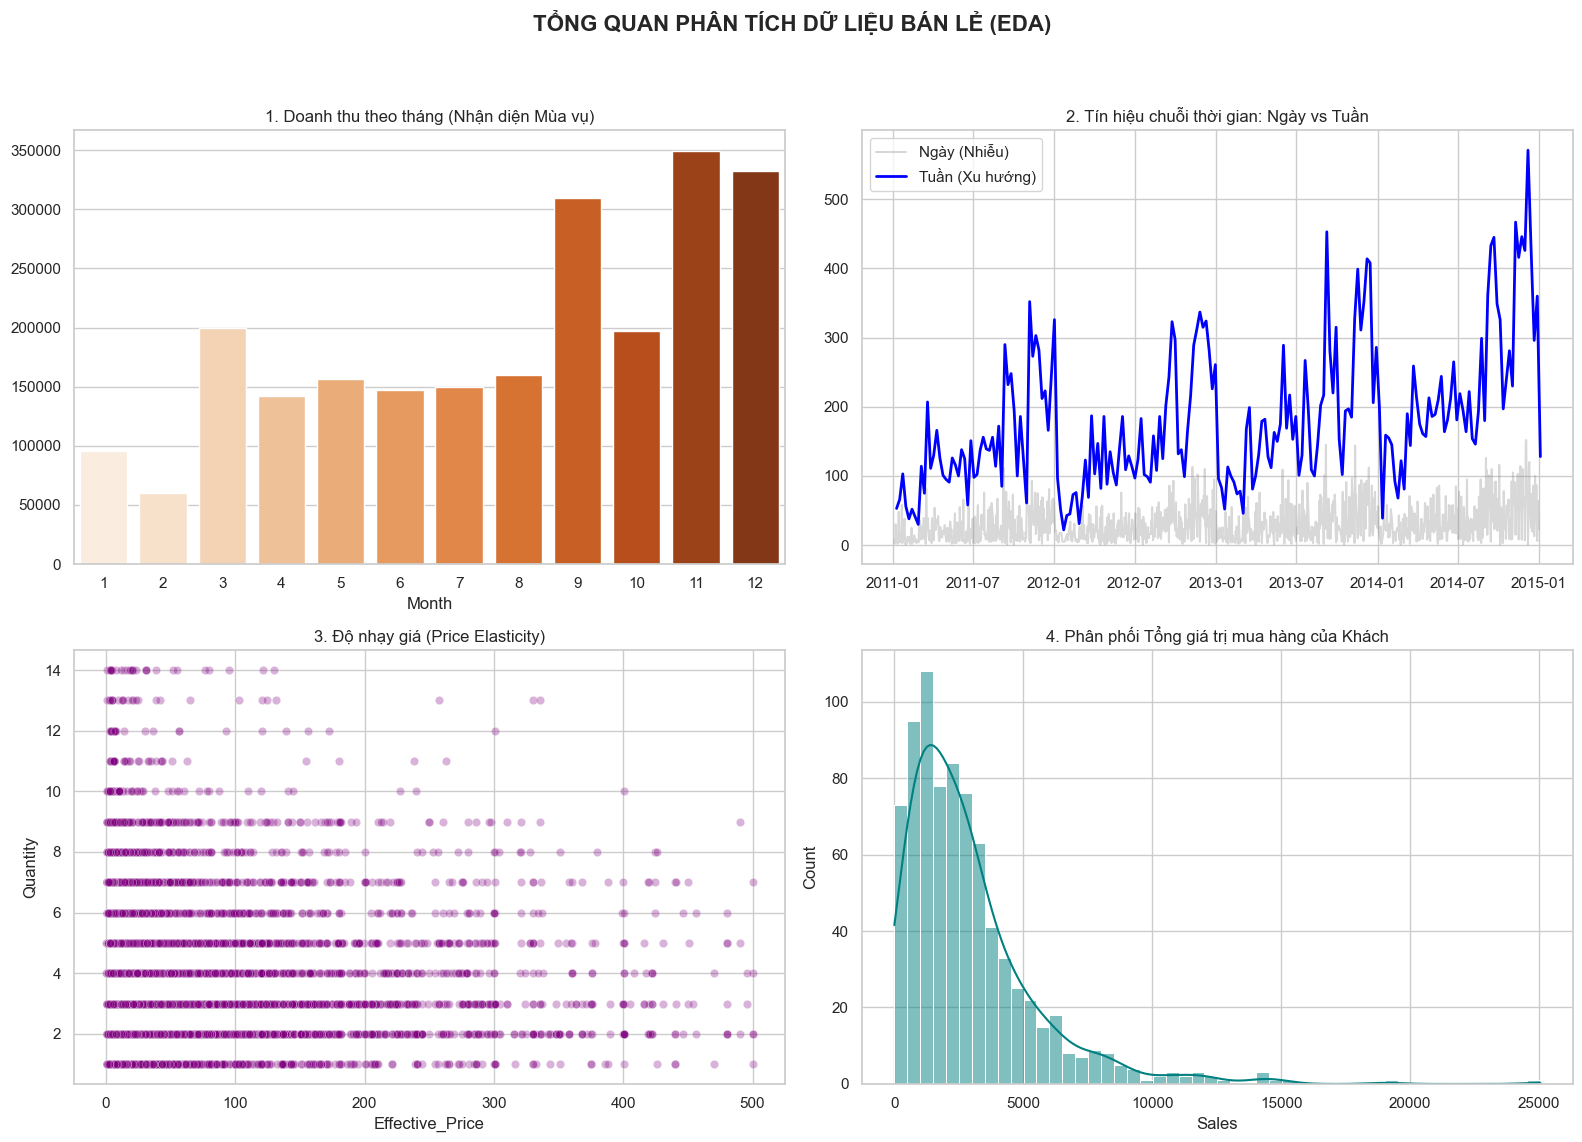

In [24]:
print("=== BƯỚC 2: EDA & TRÍCH XUẤT ĐẶC TRƯNG KINH DOANH ===")
sns.set_theme(style="whitegrid")

# 1. TRÍCH XUẤT CÁC BIẾN EDA
df_raw['Month'] = df_raw['Date'].dt.month

# Xử lý Vấn đề 1: Tính giá trị thực trả CHUẨN (Bỏ lỗi Double Discounting)
df_raw['Effective_Price'] = df_raw['Sales'] / df_raw['Quantity']

# Xử lý Vấn đề 4: Sắp xếp dữ liệu để chuẩn bị đếm User (Bỏ CLV tích lũy gây nhiễu)
df_raw = df_raw.sort_values(by=['Customer ID', 'Date'])

# 2. VẼ CÁC BIỂU ĐỒ TRỰC QUAN
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('TỔNG QUAN PHÂN TÍCH DỮ LIỆU BÁN LẺ (EDA)', fontsize=16, fontweight='bold')

# Biểu đồ 1: Mùa vụ
monthly_trend = df_raw.groupby('Month')['Sales'].sum()
sns.barplot(x=monthly_trend.index, y=monthly_trend.values, palette='Oranges', ax=axes[0,0])
axes[0,0].set_title('1. Doanh thu theo tháng (Nhận diện Mùa vụ)')

# Biểu đồ 2: Khử nhiễu Tuần vs Ngày
daily_q = df_raw.groupby('Date')['Quantity'].sum()
weekly_q = daily_q.resample('W').sum()
axes[0,1].plot(daily_q.index, daily_q.values, label='Ngày (Nhiễu)', color='gray', alpha=0.3)
axes[0,1].plot(weekly_q.index, weekly_q.values, label='Tuần (Xu hướng)', color='blue', linewidth=2)
axes[0,1].set_title('2. Tín hiệu chuỗi thời gian: Ngày vs Tuần')
axes[0,1].legend()

# Biểu đồ 3: Độ nhạy giá
sns.scatterplot(data=df_raw[df_raw['Effective_Price'] < 500], 
                x='Effective_Price', y='Quantity', alpha=0.3, color='purple', ax=axes[1,0])
axes[1,0].set_title('3. Độ nhạy giá (Price Elasticity)')

# Biểu đồ 4: Phân phối Mua hàng (Tập khách hàng)
final_sales = df_raw.groupby('Customer ID')['Sales'].sum()
sns.histplot(final_sales, bins=50, kde=True, color='teal', ax=axes[1,1])
axes[1,1].set_title('4. Phân phối Tổng giá trị mua hàng của Khách')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# PHẦN 3: XÂY DỰNG PIPELINE THEO TUẦN VÀ CHIA TẬP DỮ LIỆU
Gom nhóm dữ liệu theo tần suất tuần. Thêm biến Time_Index để xử lý hiện tượng trượt phân phối (Distribution Shift) và cấu trúc lại tập đặc trưng.

In [25]:
print("=== BƯỚC 3: WEEKLY PIPELINE & XUẤT TẬP TRAIN/TEST ===")

# --- TRƯỚC KHI GOM NHÓM TUẦN ---
# Đánh dấu 1 cho tháng 9, 11, 12 (tháng cao điểm); còn lại là 0
df_raw['Is_Peak_Season'] = df_raw['Month'].isin([9, 11, 12]).astype(int)

# --- TRONG BƯỚC GOM NHÓM TUẦN (AGGREGATION) ---
# Xử lý Vấn đề 2 & 4: Thực hiện gom nhóm duy nhất 1 lần
weekly = df_raw.groupby(['Category', pd.Grouper(key='Date', freq='W-MON')]).agg(
    Total_Quantity=('Quantity', 'sum'),
    Unique_Customers=('Customer ID', 'nunique'),
    Avg_Effective_Price=('Effective_Price', 'mean'),
    Is_Peak_Season=('Is_Peak_Season', 'max')
).reset_index().sort_values(['Category', 'Date']).reset_index(drop=True)

# Xử lý Vấn đề 3: Thêm Time_Index mô phỏng đà tăng trưởng tuyến tính
weekly['Time_Index'] = weekly.groupby('Category').cumcount() + 1

# --- TẠO CÁC BIẾN TRỄ (LAGS) VÀ TRUNG BÌNH TRƯỢT (ROLLING) ---
for cat in weekly['Category'].unique():
    mask = weekly['Category'] == cat
    weekly.loc[mask, 'Qty_Lag_1'] = weekly.loc[mask, 'Total_Quantity'].shift(1)
    weekly.loc[mask, 'Qty_Lag_4'] = weekly.loc[mask, 'Total_Quantity'].shift(4)
    weekly.loc[mask, 'Qty_Rolling_4w'] = weekly.loc[mask, 'Total_Quantity'].rolling(4).mean().shift(1)

# Mã hóa nhóm ngành và loại bỏ dòng rỗng do phép shift
weekly = pd.get_dummies(weekly, columns=['Category'], prefix='Cat', dtype=int)
weekly = weekly.dropna().reset_index(drop=True)

# Sắp xếp lại theo thời gian để đảm bảo tính nhất quán trước khi chia tập
weekly = weekly.sort_values('Date').reset_index(drop=True)

# --- CHIA TẬP TRAIN/TEST (TEMPORAL SPLIT) ---
features = [
    'Unique_Customers', 'Avg_Effective_Price', 'Is_Peak_Season', 'Time_Index', 
    'Qty_Lag_1', 'Qty_Lag_4', 'Qty_Rolling_4w', 
    'Cat_Furniture', 'Cat_Office Supplies', 'Cat_Technology'
]
target = 'Total_Quantity'

split_idx = int(len(weekly) * 0.8)
train_df, test_df = weekly.iloc[:split_idx], weekly.iloc[split_idx:]

# --- LƯU KẾT QUẢ ĐỂ THUẬT TOÁN SỬ DỤNG ---
output_dir = 'dataset_ready'
os.makedirs(output_dir, exist_ok=True)

train_df[features].to_csv(f"{output_dir}/X_train.csv", index=False)
test_df[features].to_csv(f"{output_dir}/X_test.csv", index=False)
train_df[[target]].to_csv(f"{output_dir}/y_train.csv", index=False)
test_df[[target]].to_csv(f"{output_dir}/y_test.csv", index=False)

print(f"-> Đã xuất thành công Pipeline với {len(features)} biến đặc trưng.")

=== BƯỚC 3: WEEKLY PIPELINE & XUẤT TẬP TRAIN/TEST ===
-> Đã xuất thành công Pipeline với 10 biến đặc trưng.


# PHẦN 4: BÁO CÁO TỔNG QUAN PIPELINE
Tổng hợp kích thước tập dữ liệu đã phân chia và nguồn gốc của các biến đặc trưng (Feature Provenance) để phục vụ giải trình mô hình.

In [36]:
print("="*85)
print(f"{'TỔNG HỢP: KÍCH THƯỚC DỮ LIỆU & BẢNG GIA PHẢ ĐẶC TRƯNG':^85}")
print("="*85)

# 1. BÁO CÁO KÍCH THƯỚC
try:
    X_train = pd.read_csv("dataset_ready/X_train.csv")
    X_test = pd.read_csv("dataset_ready/X_test.csv")
    total_rows = X_train.shape[0] + X_test.shape[0]
    
    print(" 1. KÍCH THƯỚC DỮ LIỆU SAU KHI GOM NHÓM (RESAMPLING):")
    print(f"   - Tổng số dữ liệu  : {total_rows} dòng")
    print(f"   - Tập Huấn luyện   : {X_train.shape[0]} dòng x {X_train.shape[1]} đặc trưng")
    print(f"   - Tập Kiểm thử     : {X_test.shape[0]} dòng x {X_test.shape[1]} đặc trưng")
    print("   - Tỷ lệ chia tập   : ~80% Train / 20% Test (Theo thời gian)\n")
except Exception as e: 
    print(f"Lỗi đọc file: {e}")

# 2. BẢNG GIA PHẢ ĐẶC TRƯNG ĐÃ CẬP NHẬT
print(" 2. BẢNG NGUỒN GỐC & CÁC BƯỚC BIẾN ĐỔI ĐẶC TRƯNG (FEATURE PROVENANCE):")
feature_mapping = {
    "Tên Đặc Trưng (X)": [
        "1. Qty_Lag_1", "2. Qty_Lag_4", "3. Qty_Rolling_4w",
        "4. Unique_Customers", "5. Avg_Effective_Price",
        "6. Is_Peak_Season", "7. Time_Index",
        "8. Cat_Office", "9. Cat_Furniture", "10. Cat_Tech"
    ],
    "Từ Cột gốc": [
        "Qty, Date", "Qty, Date", "Qty, Date",
        "Customer ID", "Sales, Qty", "Date", "Date",
        "Category", "Category", "Category"
    ],
    "Công thức biến đổi (Logic)": [
        "Dịch lùi 1 Tuần (Tự tương quan ngắn hạn)",
        "Dịch lùi 4 Tuần (Chu kỳ theo tháng)",
        "Trung bình 4 Tuần (Nhiệt kế thị trường)",
        "Đếm KH mua hàng ",
        "Sales / Qty ",
        "Gắn mác Tháng cao điểm (9, 11, 12)",
        "Mô phỏng đà tăng trưởng (Chống Target Shift)",
        "One-Hot Encoding", "One-Hot Encoding", "One-Hot Encoding"
    ]
}

df_mapping = pd.DataFrame(feature_mapping)
print("-" * 85)
for index, row in df_mapping.iterrows():
    print(f"{row['Tên Đặc Trưng (X)']:<23} | {row['Từ Cột gốc']:<15} | {row['Công thức biến đổi (Logic)']}")
print("-" * 85)

                TỔNG HỢP: KÍCH THƯỚC DỮ LIỆU & BẢNG GIA PHẢ ĐẶC TRƯNG                
 1. KÍCH THƯỚC DỮ LIỆU SAU KHI GOM NHÓM (RESAMPLING):
   - Tổng số dữ liệu  : 612 dòng
   - Tập Huấn luyện   : 489 dòng x 10 đặc trưng
   - Tập Kiểm thử     : 123 dòng x 10 đặc trưng
   - Tỷ lệ chia tập   : ~80% Train / 20% Test (Theo thời gian)

 2. BẢNG NGUỒN GỐC & CÁC BƯỚC BIẾN ĐỔI ĐẶC TRƯNG (FEATURE PROVENANCE):
-------------------------------------------------------------------------------------
1. Qty_Lag_1            | Qty, Date       | Dịch lùi 1 Tuần (Tự tương quan ngắn hạn)
2. Qty_Lag_4            | Qty, Date       | Dịch lùi 4 Tuần (Chu kỳ theo tháng)
3. Qty_Rolling_4w       | Qty, Date       | Trung bình 4 Tuần (Nhiệt kế thị trường)
4. Unique_Customers     | Customer ID     | Đếm KH mua hàng 
5. Avg_Effective_Price  | Sales, Qty      | Sales / Qty 
6. Is_Peak_Season       | Date            | Gắn mác Tháng cao điểm (9, 11, 12)
7. Time_Index           | Date            | Mô phỏng đà tăng trư

# PHẦN 5: XÂY DỰNG MÔ HÌNH HỌC MÁY (MACHINE LEARNING FROM SCRATCH)
Triển khai các thuật toán dự báo cốt lõi bằng phương pháp lập trình hướng đối tượng (OOP). Các mô hình được xây dựng từ nguyên lý cơ bản (từ đầu - from scratch) nhằm kiểm soát hoàn toàn quá trình huấn luyện qua từng vòng lặp (Epoch/Iteration).

Các chỉ số đánh giá:
- MAE (Mean Absolute Error): Sai số tuyệt đối trung bình.
- MSE (Mean Squared Error): Sai số bình phương trung bình.
- RMSE (Root Mean Squared Error): Căn bậc hai sai số bình phương trung bình.
- R2 Score: Hệ số xác định, thể hiện mức độ giải thích của mô hình đối với dữ liệu.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. HÀM ĐÁNH GIÁ MÔ HÌNH (METRICS)
def calculate_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_residual / ss_total) if ss_total != 0 else 0
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}

# 2. CÔNG CỤ CHUẨN HÓA DỮ LIỆU TỰ XÂY DỰNG (CUSTOM SCALER)
class CustomStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        
    def fit_transform(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1e-8 # Tránh lỗi chia cho 0
        return (X - self.mean_) / self.std_
    
    def transform(self, X):
        return (X - self.mean_) / self.std_

# 3. NẠP DỮ LIỆU ĐÃ LÀM SẠCH TỪ BƯỚC TRƯỚC
try:
    X_train_raw = pd.read_csv("dataset_ready/X_train.csv").values
    y_train_raw = pd.read_csv("dataset_ready/y_train.csv").values.flatten()
    X_test_raw = pd.read_csv("dataset_ready/X_test.csv").values
    y_test_raw = pd.read_csv("dataset_ready/y_test.csv").values.flatten()
    
    scaler = CustomStandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)
    y_train = y_train_raw.copy()
    y_test = y_test_raw.copy()
    print("-> Đã nạp và chuẩn hóa dữ liệu thành công chuẩn bị cho huấn luyện.")
except Exception as e:
    print(f"Lỗi đọc dữ liệu: {e}")

-> Đã nạp và chuẩn hóa dữ liệu thành công chuẩn bị cho huấn luyện.


## 5.1. Mô hình Hồi quy Tuyến tính (Linear Regression)
Sử dụng thuật toán Tối ưu hóa Cận biên (Gradient Descent) để tìm kiếm trọng số tối ưu.

In [28]:
class CustomLinearRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.name = "Linear Regression"
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []
        
        for epoch in range(self.epochs):
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Tính toán Gradient
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            
            # Cập nhật trọng số
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Ghi nhận hàm mất mát (MSE)
            loss = np.mean((y - y_predicted) ** 2)
            self.loss_history.append(loss)
            
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

## 5.2. Nhóm mô hình Cây quyết định và Học kết hợp (Tree-based & Ensemble)
Bao gồm Cây quyết định (Decision Tree) cơ sở, Rừng ngẫu nhiên (Random Forest) áp dụng kỹ thuật Bagging, và Gradient Boosting áp dụng kỹ thuật tối ưu phần dư qua từng vòng lặp (Epochs).

In [29]:
import numpy as np

# --- 1. CÂY QUYẾT ĐỊNH CƠ SỞ 
class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class CustomDecisionTree:
    def __init__(self, min_samples_split=2, max_depth=5, max_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.max_features = max_features # Thêm tham số kiểm soát số lượng features
        self.root = None
        self.name = "Decision Tree"
        
    def _calculate_variance(self, y):
        if len(y) == 0: return 0
        return np.var(y)
        
    def _best_split(self, X, y):
        best_variance_reduction = -1
        best_split_params = {}
        n_samples, n_features = X.shape
        current_variance = self._calculate_variance(y)
        
        # CƠ CHẾ FEATURE SUBSAMPLING CHO RANDOM FOREST
        feature_indices = np.arange(n_features)
        if self.max_features == 'sqrt':
            num_features = max(1, int(np.sqrt(n_features)))
            feature_indices = np.random.choice(n_features, num_features, replace=False)
        
        # Chỉ xét duyệt qua các features đã được chọn ngẫu nhiên
        for feature_idx in feature_indices:
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = X[:, feature_idx] > threshold
                
                if sum(left_mask) == 0 or sum(right_mask) == 0:
                    continue
                    
                y_left, y_right = y[left_mask], y[right_mask]
                frac_left = len(y_left) / n_samples
                frac_right = len(y_right) / n_samples
                
                variance_reduction = current_variance - (frac_left * self._calculate_variance(y_left) + frac_right * self._calculate_variance(y_right))
                
                if variance_reduction > best_variance_reduction:
                    best_variance_reduction = variance_reduction
                    best_split_params = {'feature': feature_idx, 'threshold': threshold, 'left_mask': left_mask, 'right_mask': right_mask}
                    
        return best_split_params

    def _build_tree(self, X, y, depth=0):
        n_samples = X.shape[0]
        if n_samples >= self.min_samples_split and depth < self.max_depth:
            split = self._best_split(X, y)
            if split:
                left_subtree = self._build_tree(X[split['left_mask']], y[split['left_mask']], depth + 1)
                right_subtree = self._build_tree(X[split['right_mask']], y[split['right_mask']], depth + 1)
                return TreeNode(feature=split['feature'], threshold=split['threshold'], left=left_subtree, right=right_subtree)
        
        return TreeNode(value=np.mean(y))
        
    def fit(self, X, y):
        self.root = self._build_tree(X, y)
        
    def _predict_single(self, x, tree):
        if tree.value is not None:
            return tree.value
        if x[tree.feature] <= tree.threshold:
            return self._predict_single(x, tree.left)
        return self._predict_single(x, tree.right)
        
    def predict(self, X):
        return np.array([self._predict_single(x, self.root) for x in X])

# --- 2. RỪNG NGẪU NHIÊN CHUẨN (CẬP NHẬT SỐ LƯỢNG VÀ SUBSAMPLING) ---
class CustomRandomForest:
    # Đã tăng n_estimators lên 50 để mô hình hội tụ và ổn định hơn
    def __init__(self, n_estimators=50, max_depth=5):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []
        self.name = "Random Forest"
        
    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        for _ in range(self.n_estimators):
            # 1. Row Subsampling (Bagging - Random samples with replacement)
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X[indices], y[indices]
            
            # 2. Feature Subsampling (max_features='sqrt') được kích hoạt
            tree = CustomDecisionTree(max_depth=self.max_depth, max_features='sqrt')
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            
    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(tree_preds, axis=0)

# PHẦN 6: HUẤN LUYỆN ĐỒNG LOẠT VÀ ĐÁNH GIÁ MÔ HÌNH
Tiến hành khởi tạo, chạy vòng lặp huấn luyện cho toàn bộ danh sách mô hình, tính toán chỉ số và trực quan hóa kết quả.

Đang tiến hành huấn luyện các mô hình từ đầu (Quá trình này có thể mất vài giây)...
-> Hoàn thành huấn luyện: Linear Regression
-> Hoàn thành huấn luyện: Decision Tree
-> Hoàn thành huấn luyện: Random Forest
-> Hoàn thành huấn luyện: Gradient Boosting

               BẢNG ĐÁNH GIÁ KẾT QUẢ CÁC THUẬT TOÁN (TỰ XÂY DỰNG)               


,MAE,MSE,RMSE,R2 Score
Model,,,,
Linear Regression,12.8150,339.7878,18.4333,0.9272
Decision Tree,16.6925,655.8550,25.6097,0.8596
Random Forest,16.4925,648.9225,25.4740,0.8610
Gradient Boosting,15.4640,479.8640,21.9058,0.8972


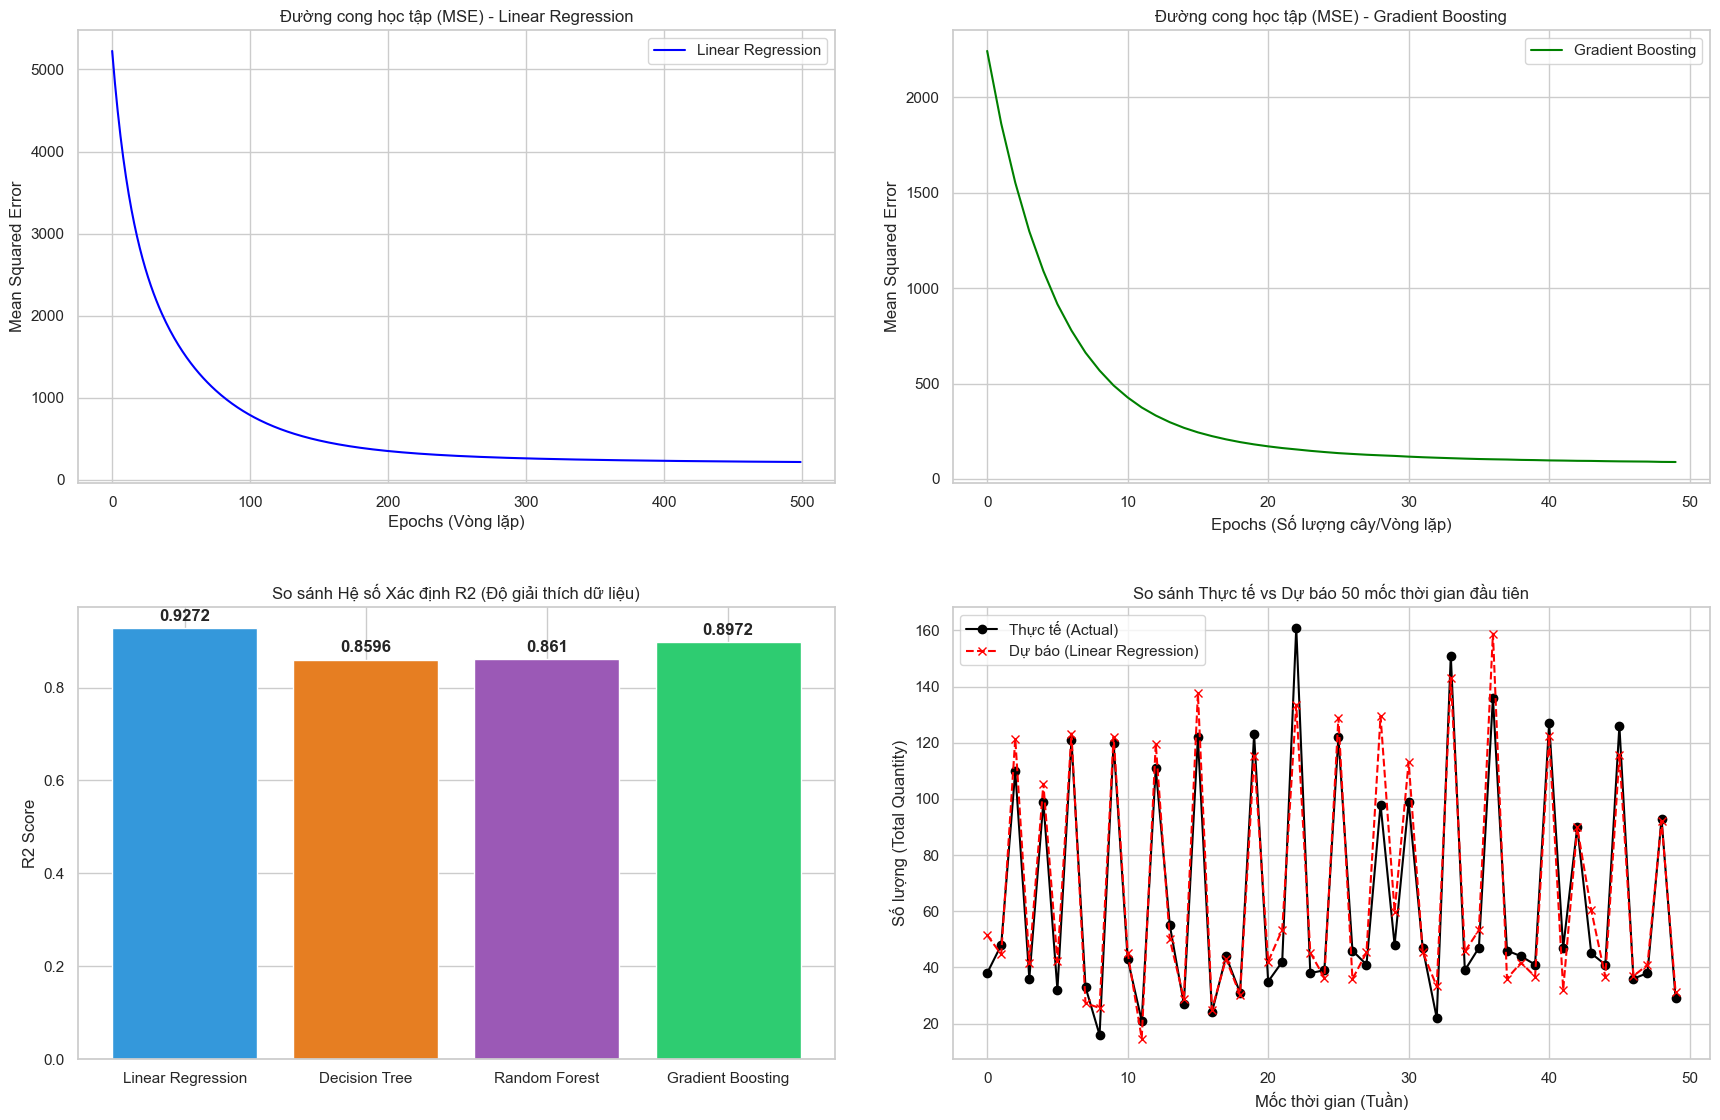

In [30]:
# 1. KHỞI TẠO DANH SÁCH MÔ HÌNH
models = [
    CustomLinearRegression(learning_rate=0.01, epochs=500),
    CustomDecisionTree(max_depth=5),
    CustomRandomForest(n_estimators=50, max_depth=5),
    CustomGradientBoosting(n_estimators=50, learning_rate=0.1, max_depth=3)
]

# 2. HUẤN LUYỆN VÀ THU THẬP KẾT QUẢ
results = []
trained_models = {}
predictions_dict = {}

print("Đang tiến hành huấn luyện các mô hình từ đầu (Quá trình này có thể mất vài giây)...")
for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    metrics = calculate_metrics(y_test, y_pred)
    metrics['Model'] = model.name
    results.append(metrics)
    
    trained_models[model.name] = model
    predictions_dict[model.name] = y_pred
    print(f"-> Hoàn thành huấn luyện: {model.name}")

# Xuất bảng tổng hợp kết quả
df_results = pd.DataFrame(results).set_index('Model')
df_results = df_results[['MAE', 'MSE', 'RMSE', 'R2 Score']]

print("\n" + "="*80)
print(f"{'BẢNG ĐÁNH GIÁ KẾT QUẢ CÁC THUẬT TOÁN (TỰ XÂY DỰNG)':^80}")
print("="*80)
display(df_results.round(4))

# 3. TRỰC QUAN HÓA (VISUALIZATIONS)
fig = plt.figure(figsize=(18, 12))

# Biểu đồ 1: Đường cong học tập (Learning Curves / Loss over Epochs)
ax1 = plt.subplot(2, 2, 1)
ax1.plot(trained_models["Linear Regression"].loss_history, label='Linear Regression', color='blue')
ax1.set_title('Đường cong học tập (MSE) - Linear Regression')
ax1.set_xlabel('Epochs (Vòng lặp)')
ax1.set_ylabel('Mean Squared Error')
ax1.legend()

ax2 = plt.subplot(2, 2, 2)
ax2.plot(trained_models["Gradient Boosting"].loss_history, label='Gradient Boosting', color='green')
ax2.set_title('Đường cong học tập (MSE) - Gradient Boosting')
ax2.set_xlabel('Epochs (Số lượng cây/Vòng lặp)')
ax2.set_ylabel('Mean Squared Error')
ax2.legend()

# Biểu đồ 2: So sánh R2 Score
ax3 = plt.subplot(2, 2, 3)
bars = ax3.bar(df_results.index, df_results['R2 Score'], color=['#3498db', '#e67e22', '#9b59b6', '#2ecc71'])
ax3.set_title('So sánh Hệ số Xác định R2 (Độ giải thích dữ liệu)')
ax3.set_ylabel('R2 Score')
for bar in bars:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom', fontweight='bold')

# Biểu đồ 3: So sánh Thực tế vs Dự báo (Cho mô hình tốt nhất - Thường là Gradient Boosting)
best_model_name = df_results['R2 Score'].idxmax()
best_y_pred = predictions_dict[best_model_name]

ax4 = plt.subplot(2, 2, 4)
time_axis = np.arange(len(y_test))[:50]
ax4.plot(time_axis, y_test[:50], marker='o', label='Thực tế (Actual)', color='black')
ax4.plot(time_axis, best_y_pred[:50], marker='x', linestyle='--', label=f'Dự báo ({best_model_name})', color='red')
ax4.set_title(f'So sánh Thực tế vs Dự báo 50 mốc thời gian đầu tiên')
ax4.set_xlabel('Mốc thời gian (Tuần)')
ax4.set_ylabel('Số lượng (Total Quantity)')
ax4.legend()

plt.tight_layout(pad=3.0)
plt.show()